# 01 - Understanding Data

## Objective
The purpose of this notebook is to understand the hotel booking dataset before performing data cleaning and preprocessing.

This step helps identify:
- Dataset structure
- Data types
- Missing values
- Outliers
- Distribution patterns
- Potential data quality issues

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Import Libraries

- pandas: used for handling tabular data
- numpy: used for numerical operations
- matplotlib: used for data visualization

In [2]:
df = pd.read_csv("../Data/hotel_bookings.csv")


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Initial Observations

- The dataset contains hotel booking information.
- Each row represents one hotel reservation.
- The dataset includes both numerical and categorical variables.
- The target variable for classification is `is_canceled`.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

## Data Information

- The dataset contains both numerical and categorical features.
- Some columns contain missing values such as `children`, `country`, and `agent`.
- Most categorical variables are stored as object type.

In [5]:
df.shape

(119390, 32)

The dataset contains 119,390 rows and 32 columns.

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## Statistical Summary

- Some numerical variables contain extreme values.
- `lead_time` has a very high maximum value.
- `adr` may contain outliers due to unusually high room prices.

In [7]:
#Check missing value 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## Missing Values

- The `company` column contains a large number of missing values.
- `agent` and `country` also contain missing data.
- Missing values need to be handled during the data cleaning phase

In [8]:
#7 CHECK TARGET VARIABLE
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

## Target Variable Distribution

- The dataset contains both canceled and non-canceled bookings.
- The classes are relatively balanced for classification analysis.

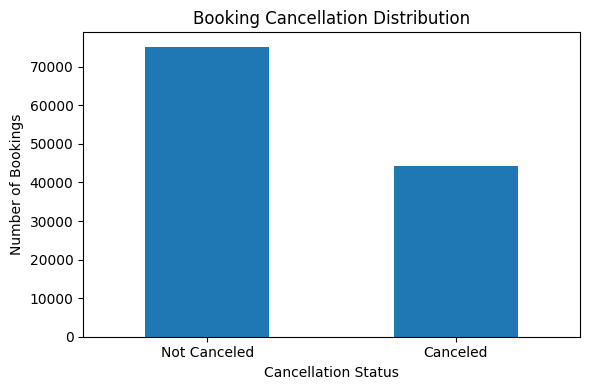

In [9]:
#7.1 Booking cancellation distribution 
cancel_counts = df['is_canceled'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

cancel_counts.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Booking Cancellation Distribution')
ax.set_xlabel('Cancellation Status')
ax.set_ylabel('Number of Bookings')

ax.set_xticklabels(['Not Canceled', 'Canceled'], rotation=0)

plt.tight_layout()
plt.show()

## Booking Cancellation Distribution

The dataset contains both canceled and non-canceled bookings.

Non-canceled bookings appear more frequently than canceled bookings, although the cancellation rate is still significant.

This indicates that booking cancellation prediction is a meaningful business problem for hotel management.

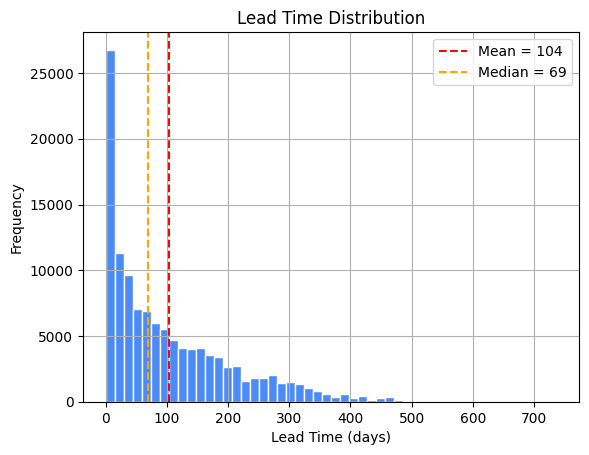

In [10]:
#8 
df['lead_time'].hist(
    bins=50,
    color='#4C8BF5',
    edgecolor='white'
)

plt.axvline(
    df['lead_time'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['lead_time'].mean():.0f}"
)

plt.axvline(
    df['lead_time'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['lead_time'].median():.0f}"
)

plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')

plt.legend()

plt.show()


## Lead Time Distribution

- The lead time variable is positively skewed.

- Most bookings were made within a relatively short period before arrival, while some bookings have extremely long lead times.

- The mean is higher than the median, indicating the presence of high-value outliers

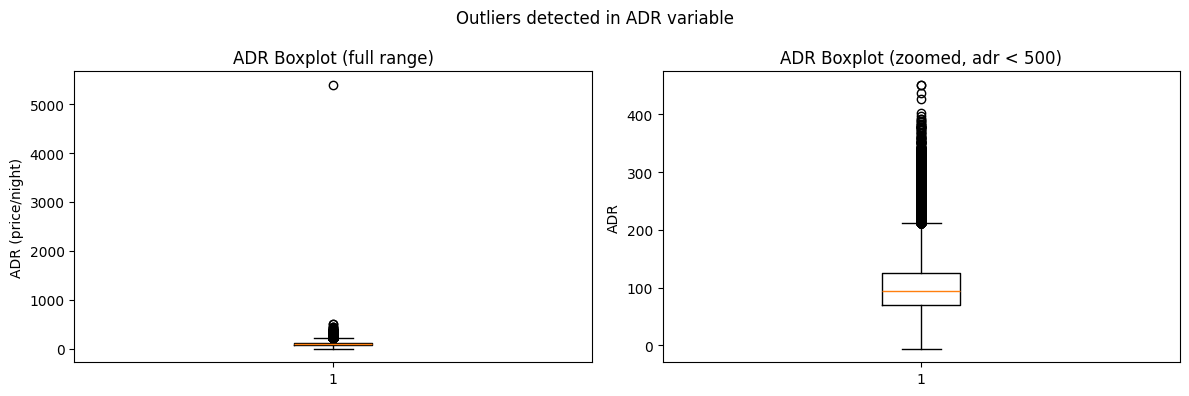

In [11]:
#9 OUTLIER DETECTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot full range
axes[0].boxplot(df['adr'])
axes[0].set_title('ADR Boxplot (full range)')
axes[0].set_ylabel('ADR (price/night)')

# Zoomed version (remove extreme values visually)
axes[1].boxplot(df[df['adr'] < 500]['adr'])
axes[1].set_title('ADR Boxplot (zoomed, adr < 500)')
axes[1].set_ylabel('ADR')

plt.suptitle('Outliers detected in ADR variable')

plt.tight_layout()
plt.show()

## Outlier Detection

- The ADR variable contains several extreme outliers and one negative value.

- A second zoomed boxplot was used to better visualize the main distribution of ADR values below 500.

- These outliers may affect model performance and should be considered during the data cleaning phase.

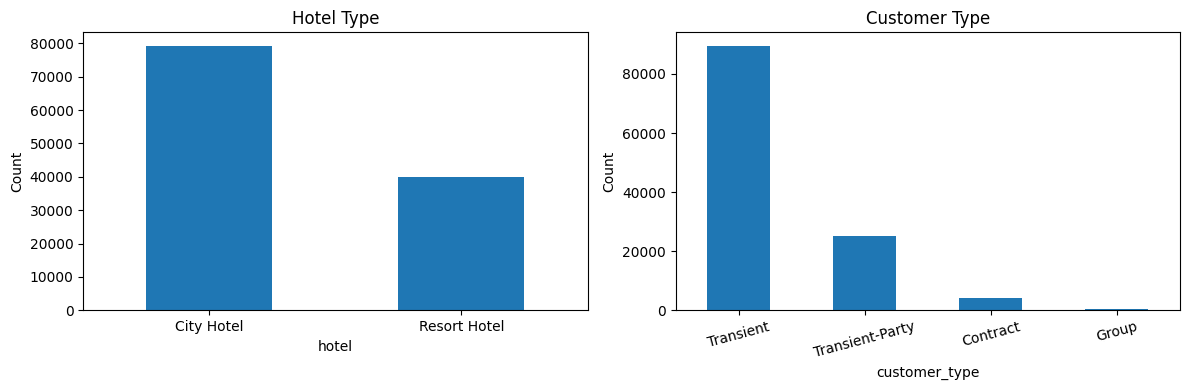

In [12]:
#10. CATEGORICAL ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hotel type distribution
df['hotel'].value_counts().plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Hotel Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Customer type distribution
df['customer_type'].value_counts().plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title('Customer Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Categorical Variable Analysis

The dataset contains different hotel and customer types.

- City Hotel bookings appear more frequently than Resort Hotel bookings.
- The majority of customers belong to the “Transient” category.

The categorical variables are not evenly distributed and may influence booking cancellation behavior.

# #11 Final conclusion 
The dataset contains hotel booking information with both numerical and categorical variables.

Several data quality issues were identified:
- Missing values in columns such as `company`, `agent`, and `country`
- Potential outliers in `adr`
- Skewed distributions in variables like `lead_time`

These issues will need to be addressed during the data cleaning and preprocessing stage before building machine learning models.
